In [2]:
import warnings
import glob
warnings.filterwarnings('ignore')
import numpy as np
print(np.__version__)
import pickle
import sys
sys.path.append('/Users/selbouch/Desktop/Chapter6/injectfrb/injectfrb/')
from spectra import Spectra
import random
import os
from tqdm import tqdm
from scipy.stats import qmc
from copy import deepcopy

2.4.6


In [3]:
#Load background data
def get_array_from_npz(npz_obj, use_db=True):
    if "data" not in npz_obj:
        raise KeyError("Missing 'data' key in npz file")

    sdata = npz_obj["data"].item()
    arr = np.array(sdata.db if use_db else sdata.amp)

    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[:, :, 0]

    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape {arr.shape}")

    return arr
input_dir = "./data_npz/snippetsHF_4768x256_BA"
file_pattern = "*.npz"
files = sorted(glob.glob(os.path.join(input_dir, file_pattern)))
path = files[0]    
n_samples = 256
d = np.load(path, allow_pickle=True)
background = get_array_from_npz(d, use_db=False)

(257, 4096)
(257, 256)


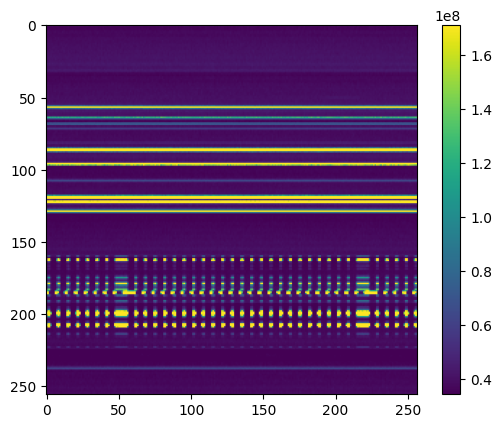

In [5]:
import matplotlib.pyplot as plt
print(background.shape)
rebinned_arr = background.reshape(257, 16, 256).mean(axis=1)
print(rebinned_arr.shape)
rebinned_arr = np.swapaxes(rebinned_arr, 0, 1)
plt.imshow(rebinned_arr, vmin=np.percentile(rebinned_arr,5), vmax=np.percentile(rebinned_arr,95), cmap="viridis")
plt.colorbar()

In [25]:
freq_list = np.linspace(400,800,256)
FREQ_REF = 200
# simulation parameters
dm = 10
snr = 10
width = 1e-3
scat_tau_ref = 1e-4
dt = 0.04
# Estimate the noise (stdev)
background_ = Spectra(freqs=freq_list, dt=dt, data = deepcopy(rebinned_arr), starttime=0, dm=dm)
background_.dedisperse(dm, ref_freq=FREQ_REF)
masked_arr = np.ma.masked_where(background_.data == 0, background_.data)
profile = np.ma.mean(masked_arr, axis=0)
sigma = np.std(profile)

In [26]:
#Simulate FRB
# create simulation
from simulate_frb import gen_simulated_frb
large_background = np.zeros((rebinned_arr.shape[0], rebinned_arr.shape[1]))
frb = gen_simulated_frb(dm = dm, fluence= 1000,  width=width,
                NFREQ=large_background.shape[0], NTIME=large_background.shape[1],
                scat_tau_ref = 1e-5, scintillate=True, spec_ind=0.0,
                background_noise = large_background, freq = (800, 400), 
                FREQ_REF = FREQ_REF, delta_t = dt, conv_dmsmear=True)

burst_masked = frb[0]
# dedisperse burst
frb_ = Spectra(freqs=freq_list, dt=dt, data = deepcopy(burst_masked), starttime=0, dm=dm)
frb_.dedisperse(dm, ref_freq=FREQ_REF)
integrated = np.mean(frb_.data, axis=0)
max_integrated = np.max(integrated)
frb_cropped = deepcopy(burst_masked)
scale_factor = snr * sigma / max_integrated
# add and scale the peak of the pulse to be the excess noise
final = deepcopy(rebinned_arr) + scale_factor * frb_cropped
final = np.swapaxes(final, 0, 1)
final = np.expand_dims(final, axis = 1)

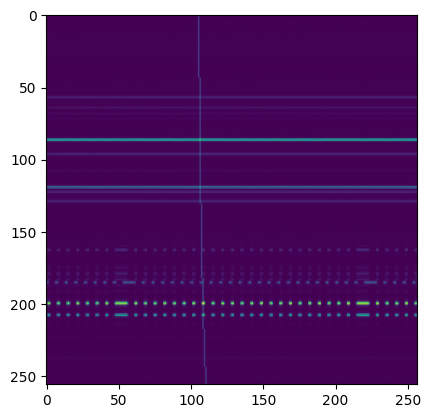

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(np.squeeze(final.T),cmap="viridis")
plt.show()